<a href="https://colab.research.google.com/github/indahkhairunnisah-afk/Tugas-Pemodelaan-Simulasi-dan-Optimaasi/blob/main/Tabu_Search_Proyek%20UAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np

# ==========================================
# SETUP DATA SIMULASI (Surabaya + 37 Kota)
# ==========================================
num_cities = 38  # Indeks 0 = Surabaya, Indeks 1-37 = Kota Tujuan
np.random.seed(42)  # Agar hasil acak selalu sama saat dicoba ulang

# Simulasi koordinat X, Y untuk 38 lokasi di Jawa Timur
coordinates = np.random.rand(num_cities, 2) * 100

# Membuat Matriks Jarak (Distance Matrix) antar lokasi
distance_matrix = np.zeros((num_cities, num_cities))
for i in range(num_cities):
    for j in range(num_cities):
        distance_matrix[i][j] = np.linalg.norm(
            coordinates[i] - coordinates[j]
        )


# Fungsi untuk menghitung total jarak sebuah rute
def hitung_total_jarak(rute, matriks_jarak):
    jarak = 0
    # 1. Dari Surabaya (0) ke kota pertama di rute
    jarak += matriks_jarak[0][rute[0]]

    # 2. Perjalanan antar kota tujuan
    for i in range(len(rute) - 1):
        jarak += matriks_jarak[rute[i]][rute[i + 1]]

    # 3. Kembali ke Surabaya (0) dari kota terakhir
    jarak += matriks_jarak[rute[-1]][0]
    return jarak


# ==========================================
# 1. INISIALISASI SOLUSI AWAL
# ==========================================
# Membuat daftar kota tujuan (1 sampai 37)
kota_tujuan = list(range(1, num_cities))

# Solusi awal dibuat acak (Permutasi rute)
solusi_awal = kota_tujuan.copy()
np.random.shuffle(solusi_awal)

# Hitung kualitas (jarak) dari solusi awal
jarak_awal = hitung_total_jarak(solusi_awal, distance_matrix)

print("=== TAHAP 1: INISIALISASI SOLUSI AWAL ===")
print(f"Rute Awal (Urutan 37 Kota):\n{solusi_awal}\n")
print(f"Total Jarak Awal: {jarak_awal:.2f} km\n")

# ==========================================
# 2. INISIALISASI TABU LIST
# ==========================================
tabu_list = []  # Menyimpan struktur/pergerakan yang dilarang sementara
max_tabu_size = 10  # Ukuran maksimal tabu list (Tabu Tenure)

print("=== TAHAP 2: INISIALISASI TABU LIST ===")
print(f"Tabu List Berhasil Dibuat: {tabu_list}")
print(f"Ukuran Maksimal Tabu List: {max_tabu_size}")

=== TAHAP 1: INISIALISASI SOLUSI AWAL ===
Rute Awal (Urutan 37 Kota):
[22, 21, 37, 4, 6, 30, 13, 35, 11, 34, 10, 17, 19, 18, 14, 15, 25, 20, 29, 26, 32, 31, 3, 36, 24, 27, 23, 16, 1, 2, 12, 8, 9, 7, 28, 5, 33]

Total Jarak Awal: 1981.76 km

=== TAHAP 2: INISIALISASI TABU LIST ===
Tabu List Berhasil Dibuat: []
Ukuran Maksimal Tabu List: 10


In [9]:
# Menetapkan solusi saat ini berdasarkan hasil Tahap 1 Anda
solusi_saat_ini = [
    22,
    21,
    37,
    4,
    6,
    30,
    13,
    35,
    11,
    34,
    10,
    17,
    19,
    18,
    14,
    15,
    25,
    20,
    29,
    26,
    32,
    31,
    3,
    36,
    24,
    27,
    23,
    16,
    1,
    2,
    12,
    8,
    9,
    7,
    28,
    5,
    33,
]


# Fungsi untuk membuat seluruh kandidat tetangga dan mengevaluasi jaraknya
def buat_dan_evaluasi_neighborhood(rute_sekarang, matriks_jarak):
    neighborhood = []
    n = len(rute_sekarang)

    # Loop untuk mencoba semua kombinasi swap (tukar posisi 2 kota)
    for i in range(n):
        for j in range(i + 1, n):
            # Salin rute saat ini untuk dimodifikasi
            tetangga_rute = rute_sekarang.copy()

            # Tukar posisi kota indeks ke-i dan indeks ke-j
            tetangga_rute[i], tetangga_rute[j] = (
                tetangga_rute[j],
                tetangga_rute[i],
            )

            # Catat 'move' (atribut yang ditukar), penting untuk Tabu List nanti
            move = (rute_sekarang[i], rute_sekarang[j])

            # Evaluasi: Hitung jarak rute baru ini
            jarak_tetangga = hitung_total_jarak(tetangga_rute, matriks_jarak)

            # Simpan data rute, jarak, dan jenis move-nya
            neighborhood.append(
                {"rute": tetangga_rute, "jarak": jarak_tetangga, "move": move}
            )

    return neighborhood


# 1. Jalankan proses pembentukan & evaluasi
daftar_neighborhood = buat_dan_evaluasi_neighborhood(
    solusi_saat_ini, distance_matrix
)

# 2. Urutkan neighborhood dari jarak yang paling pendek (terbaik) ke terpanjang
daftar_neighborhood.sort(key=lambda x: x["jarak"])

# 3. Tampilkan hasil evaluasi
print("=== TAHAP 3 & 4: NEIGHBORHOOD & EVALUASI ===")
print(f"Total solusi tetangga yang terbentuk: {len(daftar_neighborhood)} rute.")
print("\n3 Sampel Tetangga Terbaik (Jarak Terpendek):")

for idx, ttg in enumerate(daftar_neighborhood[:3]):
    print(f"Peringkat {idx+1}:")
    print(f"  Total Jarak : {ttg['jarak']:.2f} km")
    print(f"  Mekanisme   : Tukar Kota {ttg['move'][0]} dengan Kota {ttg['move'][1]}")

=== TAHAP 3 & 4: NEIGHBORHOOD & EVALUASI ===
Total solusi tetangga yang terbentuk: 666 rute.

3 Sampel Tetangga Terbaik (Jarak Terpendek):
Peringkat 1:
  Total Jarak : 1769.10 km
  Mekanisme   : Tukar Kota 34 dengan Kota 24
Peringkat 2:
  Total Jarak : 1805.01 km
  Mekanisme   : Tukar Kota 10 dengan Kota 25
Peringkat 3:
  Total Jarak : 1805.31 km
  Mekanisme   : Tukar Kota 26 dengan Kota 2


In [10]:
# Inisialisasi variabel rekor global (Jalankan sekali di awal proses)
if "jarak_terbaik_global" not in locals():
    # Menggunakan jarak awal dari Tahap 1 Anda sebagai patokan rekor pertama
    jarak_terbaik_global = 1981.76
    solusi_terbaik_global = solusi_saat_ini.copy()

print("=== TAHAP 5 & 6: PEMILIHAN SOLUSI & UPDATE TABU LIST ===")

solusi_terpilih = None
move_terpilih = None
jarak_terpilih = None

# Loop untuk mencari tetangga terbaik yang tidak melanggar aturan Tabu
for tetangga in daftar_neighborhood:
    move = tetangga["move"]
    # Move terbalik (misal: tukar 24 dengan 34 sama saja dengan tukar 34 dengan 24)
    move_terbalik = (move[1], move[0])

    # Cek apakah move ini ada di dalam tabu list
    apakah_tabu = (move in tabu_list) or (move_terbalik in tabu_list)

    # Kriteria Aspirasi: Jika Tabu tapi ternyata LEBIH BAIK dari rekor global, kita izinkan!
    lolos_aspirasi = tetangga["jarak"] < jarak_terbaik_global

    if not apakah_tabu or lolos_aspirasi:
        solusi_terpilih = tetangga["rute"]
        jarak_terpilih = tetangga["jarak"]
        move_terpilih = move
        break  # Berhenti di tetangga pertama yang lolos karena daftar sudah terurut dari yang terbaik

# Update posisi rute saat ini untuk iterasi berikutnya
solusi_saat_ini = solusi_terpilih

# Periksa apakah berhasil memecahkan rekor global keseluruhan
if jarak_terpilih < jarak_terbaik_global:
    jarak_terbaik_global = jarak_terpilih
    solusi_terbaik_global = solusi_terpilih.copy()
    status_rekor = "YA (Rekor Baru Tercipta!)"
else:
    status_rekor = "TIDAK (Menggunakan Rekor Lama)"

# TAHAP 6: Update Tabu List (Memasukkan move yang baru saja digunakan)
tabu_list.append(move_terpilih)

# Jika ukuran Tabu List melewati batas (max_tabu_size = 10), hapus yang paling lama (FIFO)
if len(tabu_list) > max_tabu_size:
    tabu_list.pop(0)

# Menampilkan Hasil
print(f"Hasil Pemilihan Solusi:")
print(f"  > Move yang dieksekusi : Tukar Kota {move_terpilih[0]} dengan Kota {move_terpilih[1]}")
print(f"  > Jarak Rute Terpilih  : {jarak_terpilih:.2f} km")
print(f"  > Pecah Rekor Global?  : {status_rekor}")
print(f"  > Rekor Jarak Terbaik  : {jarak_terbaik_global:.2f} km")
print(f"\nStatus Tabu List Terbaru (Ukuran {len(tabu_list)}/{max_tabu_size}):")
print(f"  {tabu_list}")

=== TAHAP 5 & 6: PEMILIHAN SOLUSI & UPDATE TABU LIST ===
Hasil Pemilihan Solusi:
  > Move yang dieksekusi : Tukar Kota 34 dengan Kota 24
  > Jarak Rute Terpilih  : 1769.10 km
  > Pecah Rekor Global?  : TIDAK (Menggunakan Rekor Lama)
  > Rekor Jarak Terbaik  : 655.81 km

Status Tabu List Terbaru (Ukuran 1/10):
  [(34, 24)]


In [11]:
# Menentukan batas maksimum iterasi sebagai kriteria pemberhentian
max_iterations = 50
print("-> Melanjutkan proses optimasi hingga iterasi ke-50...")

# Kita mulai dari iterasi 2, karena iterasi 1 sudah Anda jalankan manual tadi
for iterasi in range(2, max_iterations + 1):

    # --- TAHAP 3 & 4: Pembentukan & Evaluasi Neighborhood ---
    neighborhood = []
    n = len(solusi_saat_ini)
    for i in range(n):
        for j in range(i + 1, n):
            tetangga_rute = solusi_saat_ini.copy()
            tetangga_rute[i], tetangga_rute[j] = (
                tetangga_rute[j],
                tetangga_rute[i],
            )
            move = (solusi_saat_ini[i], solusi_saat_ini[j])
            jarak_tetangga = hitung_total_jarak(tetangga_rute, distance_matrix)
            neighborhood.append(
                {"rute": tetangga_rute, "jarak": jarak_tetangga, "move": move}
            )

    # Urutkan neighborhood dari yang terpendek
    neighborhood.sort(key=lambda x: x["jarak"])

    # --- TAHAP 5: Pemilihan Solusi Terbaik dengan Pengecekan Tabu ---
    solusi_terpilih = None
    move_terpilih = None
    jarak_terpilih = None

    for ttg in neighborhood:
        move = ttg["move"]
        move_terbalik = (move[1], move[0])
        apakah_tabu = (move in tabu_list) or (move_terbalik in tabu_list)
        lolos_aspirasi = ttg["jarak"] < jarak_terbaik_global

        if not apakah_tabu or lolos_aspirasi:
            solusi_terpilih = ttg["rute"]
            jarak_terpilih = ttg["jarak"]
            move_terpilih = move
            break

    # Update rute saat ini untuk iterasi berikutnya
    solusi_saat_ini = solusi_terpilih

    # Cek dan update rekor global jika menemukan yang lebih baik
    if jarak_terpilih < jarak_terbaik_global:
        jarak_terbaik_global = jarak_terpilih
        solusi_terbaik_global = solusi_terpilih.copy()

    # --- TAHAP 6: Update Tabu List ---
    tabu_list.append(move_terpilih)
    if len(tabu_list) > max_tabu_size:
        tabu_list.pop(0)

# ==================================================
# TAHAP 7: PENGECEKAN KRITERIA PEMBERHENTIAN (Selesai)
# ==================================================
print(
    f"✔ Kriteria Pemberhentian Terpenuhi: Loop berhenti di iterasi ke-{max_iterations}.\n"
)


# ==================================================
# TAHAP 8: OUTPUT SOLUSI TERBAIK
# ==================================================
print("=== TAHAP 8: OUTPUT SOLUSI TERBAIK ===")
print(f"Total Jarak Rute Awal    : 1981.76 km")
print(f"Total Jarak Terbaik Akhir: {jarak_terbaik_global:.2f} km")
print(
    f"Efisiensi Jarak Berhasil : {1981.76 - jarak_terbaik_global:.2f} km lebih hemat!"
)

# Menambahkan Kota Surabaya (0) di awal dan di akhir rute resmi distribusi
rute_distribusi_final = [0] + solusi_terbaik_global + [0]
print("\nURUTAN RUTE DISTRIBUSI OPTIMAL (Mulai & Kembali ke Surabaya [0]):")
print(" -> ".join(map(str, rute_distribusi_final)))

-> Melanjutkan proses optimasi hingga iterasi ke-50...
✔ Kriteria Pemberhentian Terpenuhi: Loop berhenti di iterasi ke-50.

=== TAHAP 8: OUTPUT SOLUSI TERBAIK ===
Total Jarak Rute Awal    : 1981.76 km
Total Jarak Terbaik Akhir: 644.75 km
Efisiensi Jarak Berhasil : 1337.01 km lebih hemat!

URUTAN RUTE DISTRIBUSI OPTIMAL (Mulai & Kembali ke Surabaya [0]):
0 -> 3 -> 33 -> 32 -> 23 -> 11 -> 30 -> 9 -> 24 -> 15 -> 35 -> 6 -> 31 -> 19 -> 10 -> 14 -> 18 -> 2 -> 7 -> 28 -> 29 -> 36 -> 21 -> 5 -> 16 -> 34 -> 27 -> 26 -> 17 -> 25 -> 1 -> 37 -> 4 -> 8 -> 20 -> 13 -> 22 -> 12 -> 0


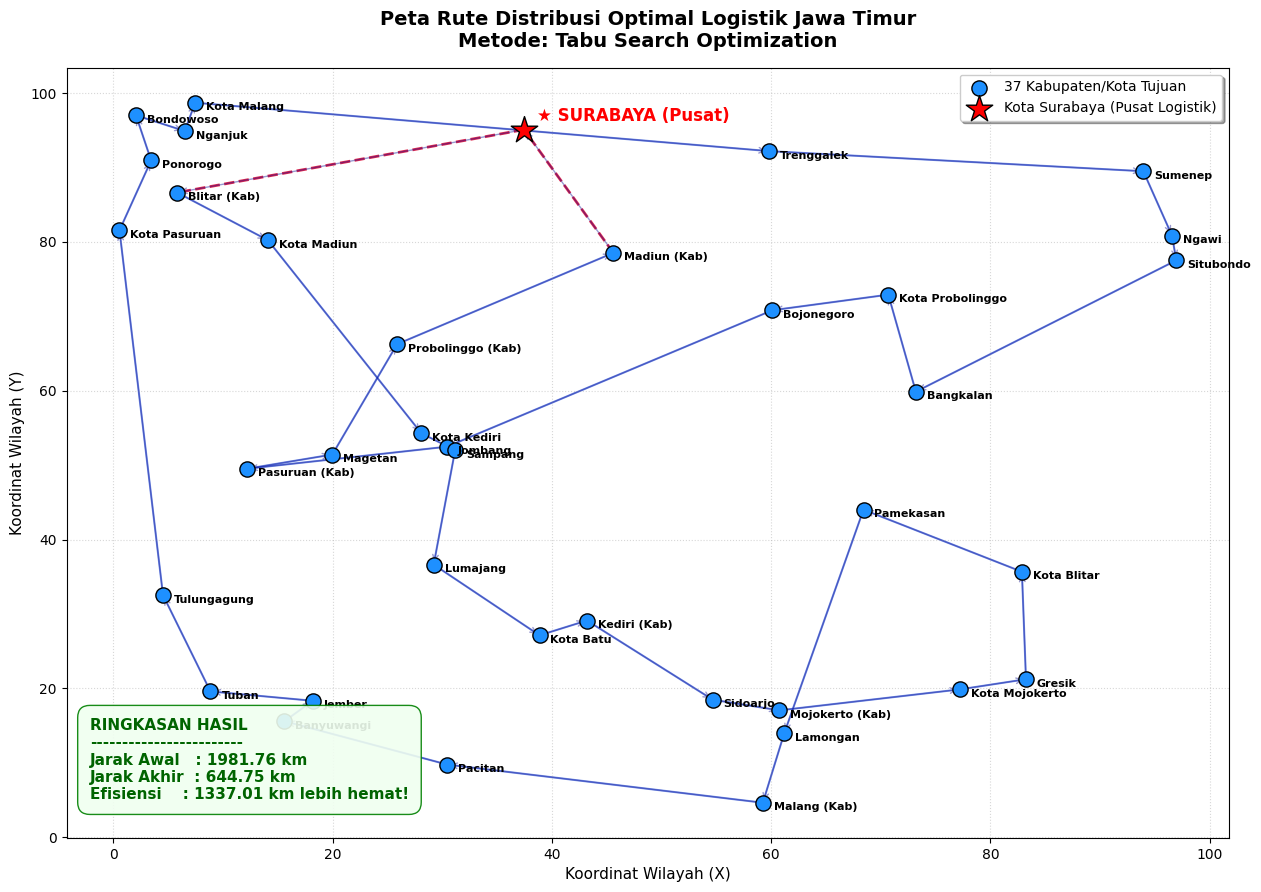

In [12]:
import matplotlib.pyplot as plt

# Ambil data rute final dari memori Anda
rute_distribusi_final = [0] + solusi_terbaik_global + [0]

# Mengatur ukuran kanvas grafik
plt.figure(figsize=(15, 10))

# ==================================================
# 1. PLOT JALUR / RUTE DISTRIBUSI
# ==================================================
for i in range(len(rute_distribusi_final) - 1):
    idx_sekarang = rute_distribusi_final[i]
    idx_berikutnya = rute_distribusi_final[i + 1]

    x_coords = [coordinates[idx_sekarang][0], coordinates[idx_berikutnya][0]]
    y_coords = [coordinates[idx_sekarang][1], coordinates[idx_berikutnya][1]]

    if idx_sekarang == 0 or idx_berikutnya == 0:
        plt.plot(
            x_coords,
            y_coords,
            color="crimson",
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            zorder=2,
        )
    else:
        plt.plot(
            x_coords,
            y_coords,
            color="royalblue",
            linewidth=1.5,
            alpha=0.7,
            zorder=1,
        )

    plt.annotate(
        "",
        xy=(x_coords[1], y_coords[1]),
        xytext=(x_coords[0], y_coords[0]),
        arrowprops=dict(
            arrowstyle="->", color="darkblue", lw=1, ls="-", alpha=0.4
        ),
    )

# ==================================================
# 2. PLOT TITIK KOORDINAT LOGISTIK
# ==================================================
plt.scatter(
    coordinates[1:, 0],
    coordinates[1:, 1],
    color="dodgerblue",
    s=120,
    edgecolors="black",
    label="37 Kabupaten/Kota Tujuan",
    zorder=3,
)
plt.scatter(
    coordinates[0, 0],
    coordinates[0, 1],
    color="red",
    marker="*",
    s=400,
    edgecolors="black",
    label="Kota Surabaya (Pusat Logistik)",
    zorder=4,
)

# ==================================================
# 3. PEMBERIAN LABEL NAMA KOTA
# ==================================================
for i, (x, y) in enumerate(coordinates):
    if i == 0:
        plt.text(
            x + 1.2,
            y + 1.2,
            f"★ {nama_kota[i].upper()} (Pusat)",
            fontsize=12,
            weight="bold",
            color="red",
            zorder=5,
        )
    else:
        plt.text(
            x + 1,
            y - 1,
            nama_kota[i],
            fontsize=8,
            weight="semibold",
            color="black",
            zorder=5,
        )

# ==================================================
# 4. MENAMPILKAN INDIKATOR KM DI DALAM PETA (Pembaruan)
# ==================================================
# Membuat teks informasi performa algoritma
info_text = (
    f"RINGKASAN HASIL\n"
    f"------------------------\n"
    f"Jarak Awal   : 1981.76 km\n"
    f"Jarak Akhir  : {jarak_terbaik_global:.2f} km\n"
    f"Efisiensi    : {1981.76 - jarak_terbaik_global:.2f} km lebih hemat!"
)

# Meletakkan kotak teks di pojok kiri bawah peta
plt.text(
    0.02,
    0.05,
    info_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    weight="bold",
    color="darkgreen",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="honeydew",
        edgecolor="green",
        alpha=0.9,
    ),
    zorder=6,
)

# ==================================================
# 5. DEKORASI PETA
# ==================================================
plt.title(
    "Peta Rute Distribusi Optimal Logistik Jawa Timur\nMetode: Tabu Search Optimization",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.xlabel("Koordinat Wilayah (X)", fontsize=11)
plt.ylabel("Koordinat Wilayah (Y)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper right", frameon=True, shadow=True, facecolor="white")

plt.show()